### Creating Text Representations

Text data needs to be converted to numeric representations before they can be used to train deep learning models. The Spam classification feature data is converted to TF-IDF vectors and the target variable is converted to one-hot encoding.

In [26]:
import pandas as pd
import os
import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import optimizers
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import preprocessing

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords


import matplotlib.pyplot as plt

In [20]:
# Load Spam Data and review content
spam_data = pd.read_csv("data/Spam-Classification.csv")


# Separate feature and target data
spam_classes_raw = spam_data["CLASS"]
spam_messages = spam_data["SMS"]

display(spam_data.head())

,CLASS,SMS
0,ham,"said kiss, kiss, i can't do the sound effects..."
1,ham,&lt;#&gt; ISH MINUTES WAS 5 MINUTES AGO. WTF.
2,spam,(Bank of Granite issues Strong-Buy) EXPLOSIVE ...
3,spam,* FREE* POLYPHONIC RINGTONE Text SUPER to 8713...
4,spam,**FREE MESSAGE**Thanks for using the Auction S...


In [21]:
# Absolute path to NLTK data
nltk_data_path = os.path.abspath("data/nltk_data")

# Ensure the directory exists
os.makedirs(nltk_data_path, exist_ok=True)

# Append the custom path to NLTK data paths
nltk.data.path.append(nltk_data_path)

# Download required NLTK data if not already present
try:
    nltk.data.find("tokenizers/punkt_tab")
except LookupError:
    nltk.download("punkt_tab", download_dir=nltk_data_path)

try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords", download_dir=nltk_data_path)


def custom_tokenizer(text):
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words("english"))
    nostop = [t for t in tokens if t.lower() not in stop_words]
    return [word.lower() for word in nostop if word.isalpha()]


# Test the tokenizer
print(word_tokenize("This is a test sentence."))
print(custom_tokenizer("This is a test sentence with Stopwords!"))

['This', 'is', 'a', 'test', 'sentence', '.']
['test', 'sentence', 'stopwords']


In [22]:
# Initialize the TfidfVectorizer with custom tokenizer
vectorizer = TfidfVectorizer(tokenizer=custom_tokenizer)

# Transform the messages into TF-IDF features
tfidf = vectorizer.fit_transform(spam_messages)

# Convert the sparse matrix to a dense format
tfidf_array = tfidf.toarray()

# build label encoder for target variable to convert strings to numerical values
label_encoder = preprocessing.LabelEncoder()
spam_classes = label_encoder.fit_transform(spam_classes_raw)


# Convert target to one-hot encoding
spam_classes = tf.keras.utils.to_categorical(spam_classes, num_classes=2)


display(f"TF-IDF Matrix Shape: {tfidf_array.shape}")
display(f"One-hot Encoding Shape: {spam_classes.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    tfidf_array,
    spam_classes,
    test_size=0.10,
)

/opt/ml-tutorial/flowr-classification-dp/.venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


'TF-IDF Matrix Shape: (1500, 3299)'

'One-hot Encoding Shape: (1500, 2)'

In [23]:
NB_CLASSES = 2
N_HIDDEN = 32


model = tf.keras.Sequential()

model.add(keras.layers.Dense(N_HIDDEN, activation="relu",  name='Hidden-Layer-1', input_shape=(X_train.shape[1],)))

model.add(keras.layers.Dense(N_HIDDEN, activation="relu", name='Hidden-Layer-2'))

model.add(keras.layers.Dense(NB_CLASSES, activation="softmax", name='Output-Layer'))

model.compile(loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

/opt/ml-tutorial/flowr-classification-dp/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden-Layer-1 (Dense)          │ (None, 32)             │       105,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden-Layer-2 (Dense)          │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output-Layer (Dense)            │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,722 (416.88 KB)

 Trainable params: 106,722 (416.88 KB)

 Non-trainable params: 0 (0.00 B)

'Training the model...'

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9984 - loss: 0.0635 - val_accuracy: 0.9630 - val_loss: 0.1555
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9988 - loss: 0.0548 - val_accuracy: 0.9630 - val_loss: 0.1437
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9983 - loss: 0.0470 - val_accuracy: 0.9667 - val_loss: 0.1402
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9973 - loss: 0.0415 - val_accuracy: 0.9593 - val_loss: 0.1414
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9986 - loss: 0.0344 - val_accuracy: 0.9630 - val_loss: 0.1290
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9991 - loss: 0.0299 - val_accuracy: 0.9667 - val_loss: 0.1287
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9990 - loss: 0.0256 - val_accuracy: 0.9667 - val_loss: 0.1245
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9997 - loss: 0.0201 - val_accuracy: 0.9630 - val_loss: 0.1266


'Accuracy during training:'

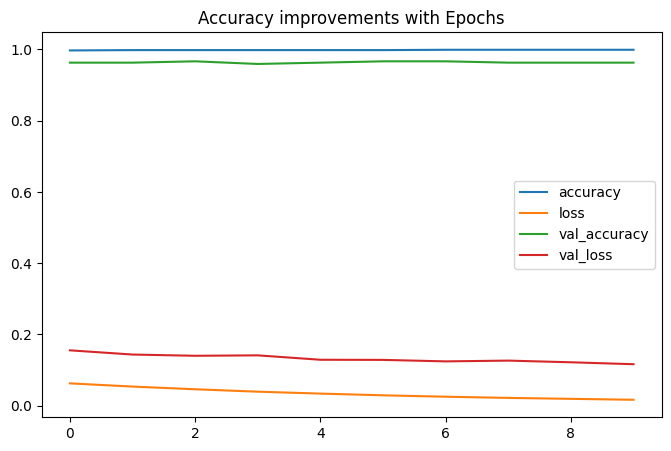

'Evaluation of the model...'

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9528 - loss: 0.1448 


'Evaluation results:'

[0.13275176286697388, 0.95333331823349]

In [27]:
VERBOSE = 1

BATCH_SIZE = 256

EPOCHS = 10

VALIDATION_SPLIT = 0.2


display("Training the model...")

model_history = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=VERBOSE,
    validation_split=VALIDATION_SPLIT,
)


display("Accuracy during training:")    

pd.DataFrame(model_history.history).plot(figsize=(8, 5))
plt.title("Accuracy improvements with Epochs")  
plt.show()

display("Evaluation of the model...")   

evaluation_results = model.evaluate(X_test, y_test, verbose=VERBOSE)
display("Evaluation results:", evaluation_results)

In [ ]:
predict_tfidf = vectorizer.transform(["Congratulations! You've won a lottery!","Yup I am coming to the party!"]).toarray()

display(predict_tfidf.shape)

predictions = np.argmax(model.predict(predict_tfidf), axis=1)

display("Predictions:", predictions)

display("Predictions (Spam/Not Spam):", label_encoder.inverse_transform(predictions))

(2, 3299)